In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



In [3]:
df=pd.read_csv(r'C:\Users\Brithi S\Desktop\study_performance.csv')

In [4]:
print(df.head())

   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [5]:
print(df.columns)

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')


In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [15]:
X = df_encoded[['reading_score']]
y = df_encoded['writing_score']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
print("\nModel Performance:")
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))



Model Performance:
R2 Score: 0.9154964112229643
MSE: 21.906946025678547
MAE: 3.6737022607831356


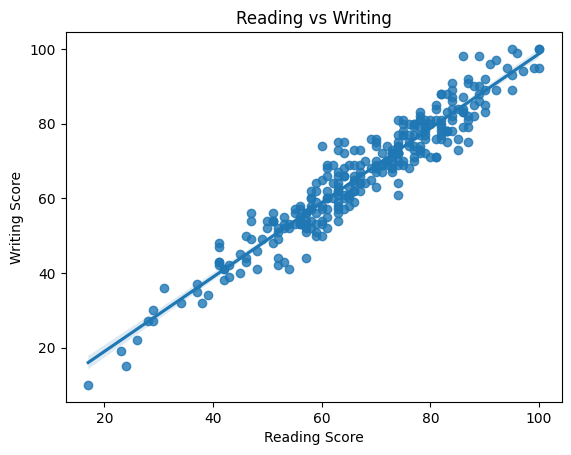

In [19]:
plt.figure()
sns.regplot(x=X_test.squeeze(), y=y_test)
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing")
plt.show()

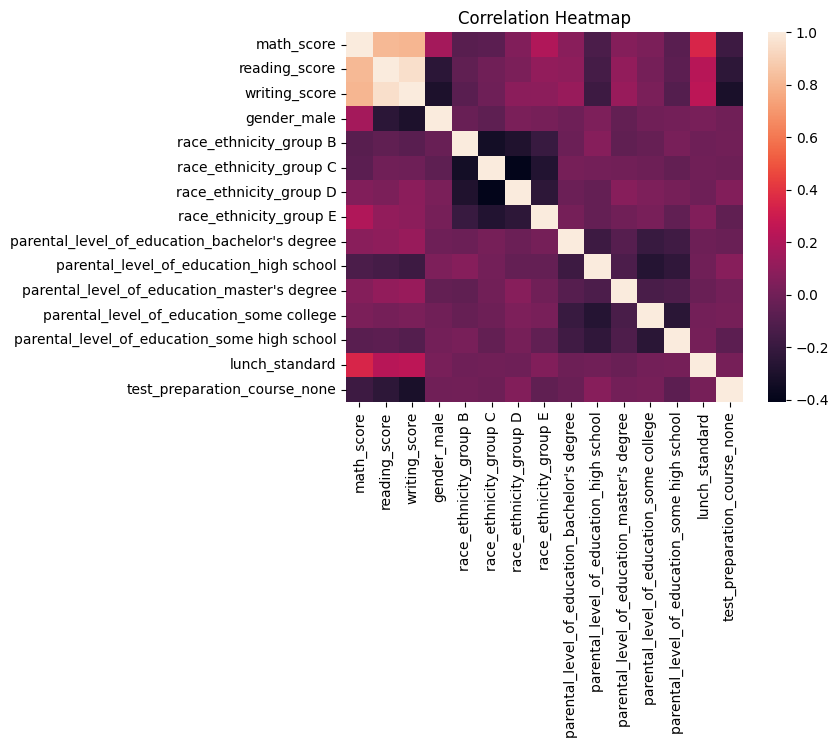

In [20]:
plt.figure()
sns.heatmap(df_encoded.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()